In [1]:
import numpy as np
import proximitygraphs as pg
from proximitygraphs.experiments import Experiment

# EXAMPLE 1: Basic Experiment - Comparing Gabriel vs RNG

In [2]:
def example_basic_comparison():
    """Compare Gabriel Graph and RNG on uniform point sets."""
    

    exp = Experiment(
        name="Gabriel vs RNG on Uniform Points",
        point_config={
            'method': 'uniform_square',
            'params': {'n': 100}
        },
        graph_configs=[
            {'class': pg.GG, 'params': {'closed': True}, 'name': 'Gabriel'},
            {'class': pg.RNG, 'params': {'closed': False}, 'name': 'RNG'}
        ],
        n_simulations=30,
        seed=42,
        verbose=True
    )
    
    # Run experiment
    results = exp.run()
    
    # View summary
    print("\n" + exp.summary())
    
    # Plot comparison
    fig, ax = exp.plot_metric('mean_degree', kind='bar')
    fig.savefig(r'tests/Experiment_figs/ex1_degree_comparison.png', dpi=150, bbox_inches='tight')
    
    # Compare multiple metrics
    fig, axes = exp.compare_metrics(
        metrics=['mean_degree', 'n_edges', 'mean_length', 'density']
    )
    fig.savefig(r'tests/Experiment_figs/ex1_multi_metric.png', dpi=150, bbox_inches='tight')
    
    # Export results
    exp.export_results(r'tests/Experimet_results/exp1_results.csv', format='csv')
    
    return exp

Running experiment: Gabriel vs RNG on Uniform Points
Simulations: 30
Graph types: 2
--------------------------------------------------
Progress: 3/30 simulations
Progress: 6/30 simulations
Progress: 9/30 simulations
Progress: 12/30 simulations
Progress: 15/30 simulations
Progress: 18/30 simulations
Progress: 21/30 simulations
Progress: 24/30 simulations
Progress: 27/30 simulations
Progress: 30/30 simulations
--------------------------------------------------
Experiment complete. 60 results collected.

Experiment: Gabriel vs RNG on Uniform Points
Simulations: 30
Graph types: Gabriel, RNG

Aggregated Results:
------------------------------------------------------------
           n_vertices                    n_edges                      \
                 mean  std  min  max        mean       std  min  max   
graph_type                                                             
Gabriel         100.0  0.0  100  100  178.366667  6.408418  164  196   
RNG             100.0  0.0  100  100

Experiment('Gabriel vs RNG on Uniform Points', simulations=30, status=60 results)

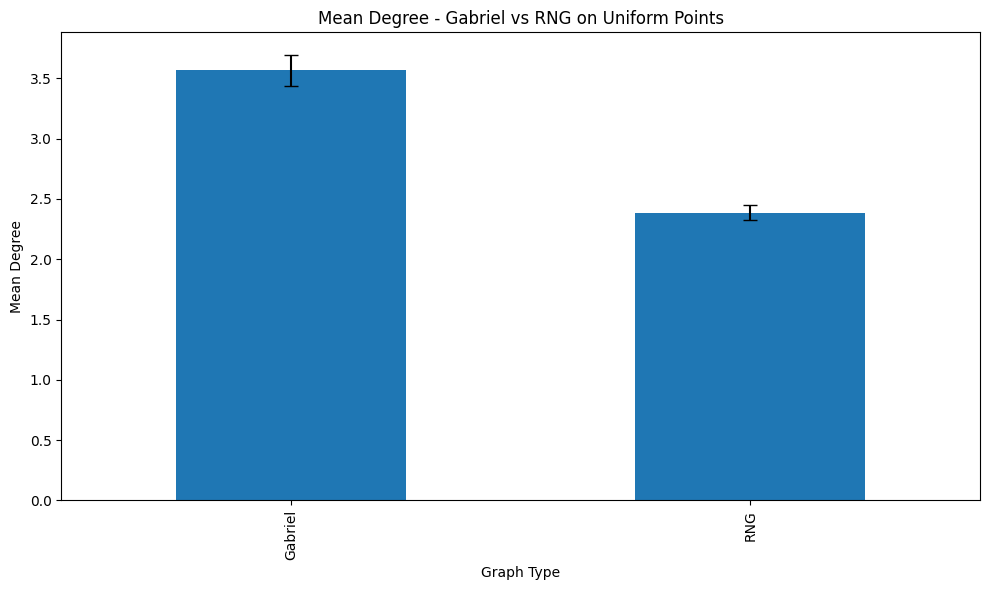

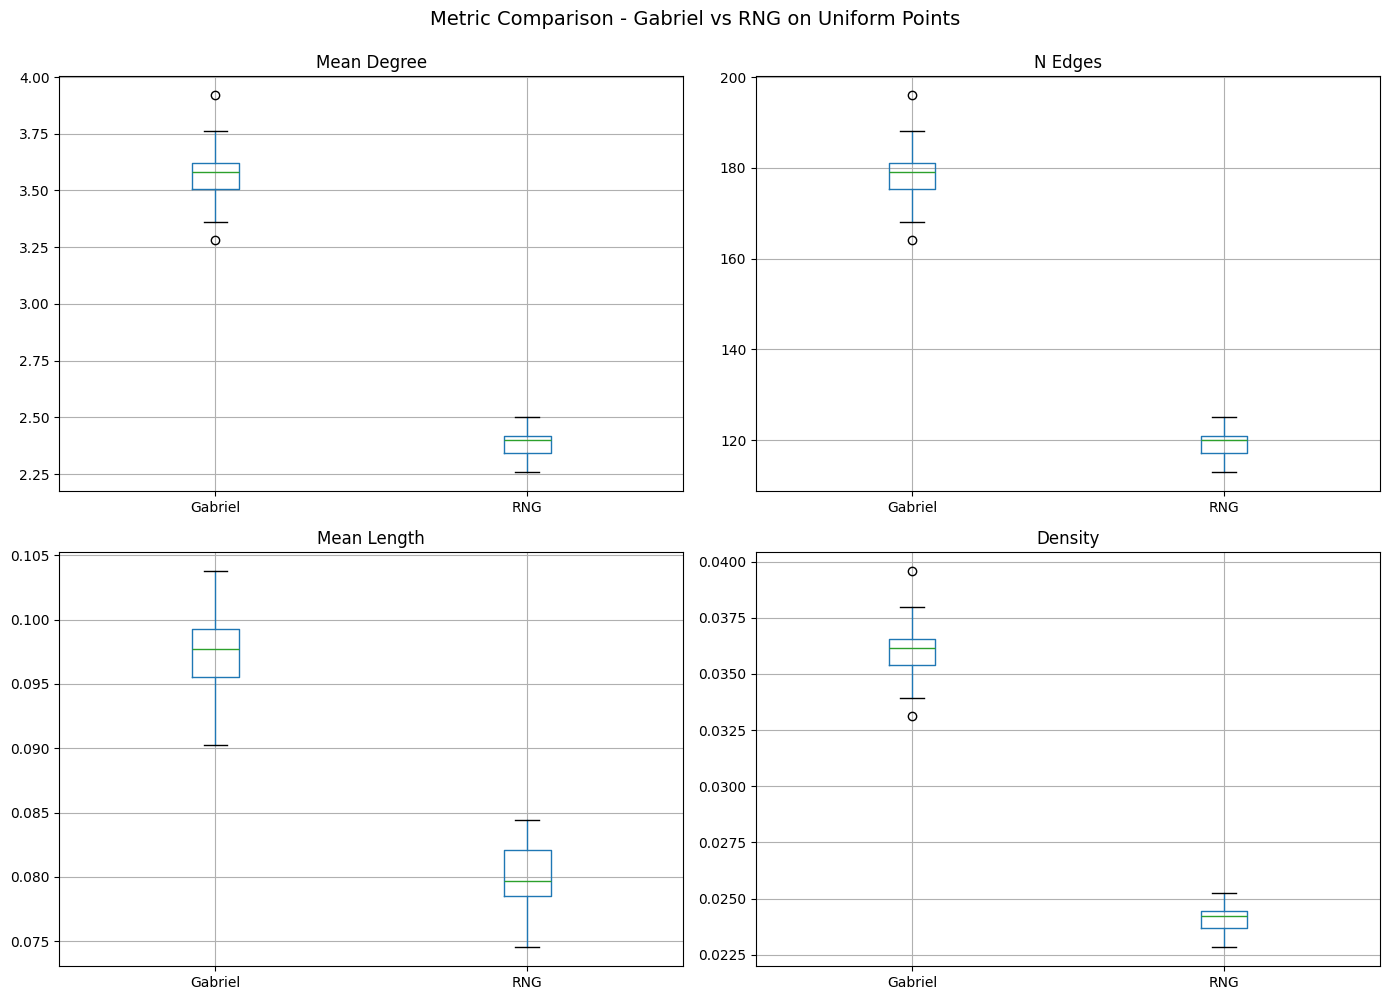

In [3]:
example_basic_comparison()

# EXAMPLE 2: Multiple Graph Types with Different Point Distributions

In [4]:
def example_multiple_graphs():
    """Compare multiple graph types on Poisson point process."""
    
    exp = Experiment(
        name="Proximity Graphs on Poisson Process",
        n_simulations=40,
        seed=123
    )
    
    # Configure point generation
    exp.add_point_config('poissonprocess_square', intensity=50, limit=1)
    
    # Add multiple graph types
    exp.add_graph_config(pg.GG, name='Gabriel', closed=True)
    exp.add_graph_config(pg.RNG, name='RNG', closed=False)
    exp.add_graph_config(pg.DelaunayG, name='Delaunay')
    exp.add_graph_config(pg.MST, name='MST')
    exp.add_graph_config(pg.Beta_Skeleton, name='Beta-1.5', beta=1.5)
    
    # Run
    results = exp.run()
    
    # Aggregate and view
    agg = exp.aggregate()
    print("\nAggregated Results:")
    print(agg[['mean_degree', 'n_edges', 'n_components']])
    
    # Plot degree distribution
    fig, ax = exp.plot_metric('mean_degree', kind='box')
    fig.savefig(r'tests/Experiment_figs/ex2_degree_box.png', dpi=150, bbox_inches='tight')
    
    return exp

c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:114: UserWarning: No point configuration provided. Use add_point_config().
  warnings.warn("No point configuration provided. Use add_point_config().")
c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:117: UserWarning: No graph configurations provided. Use add_graph_config().
  warnings.warn("No graph configurations provided. Use add_graph_config().")


Running experiment: Proximity Graphs on Poisson Process
Simulations: 40
Graph types: 5
--------------------------------------------------
Progress: 4/40 simulations
Progress: 8/40 simulations
Progress: 12/40 simulations
Progress: 16/40 simulations
Progress: 20/40 simulations
Progress: 24/40 simulations
Progress: 28/40 simulations
Progress: 32/40 simulations
Progress: 36/40 simulations
Progress: 40/40 simulations
--------------------------------------------------
Experiment complete. 200 results collected.

Aggregated Results:
           mean_degree                                n_edges                 \
                  mean       std       min       max     mean        std min   
graph_type                                                                     
Beta-1.5      2.647334  0.122023  2.260870  2.851064   64.600   9.721243  44   
Delaunay      5.472951  0.107149  5.151515  5.666667  133.675  20.286901  85   
Gabriel       3.412354  0.170093  2.869565  3.739130   83.225  12.44

Experiment('Proximity Graphs on Poisson Process', simulations=40, status=200 results)

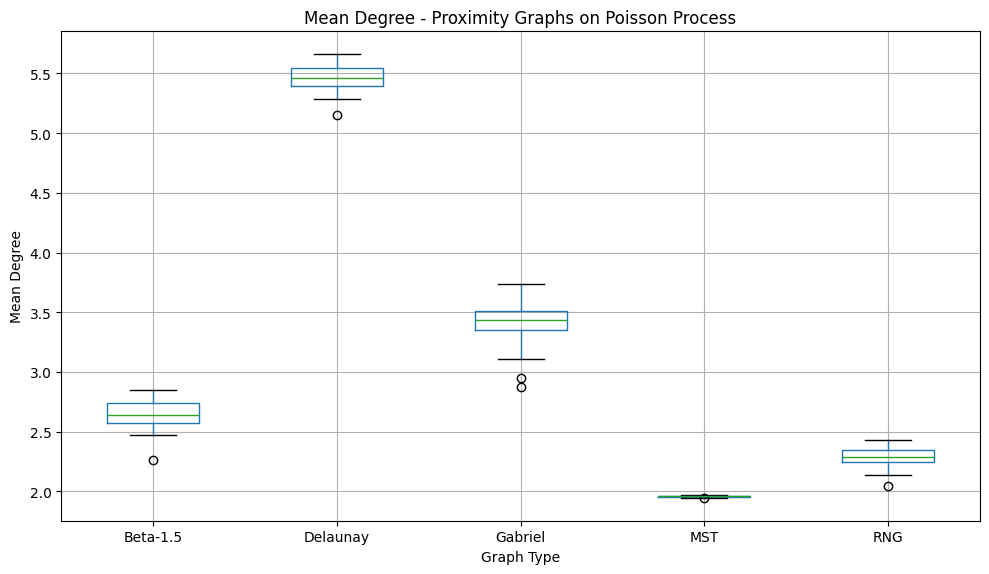

In [5]:
example_multiple_graphs()

# EXAMPLE 3: Custom Metrics

In [6]:
def example_custom_metrics():
    
    # Define custom metrics
    def edge_length_variance(graph):
        """Variance of edge lengths."""
        if graph.m == 0:
            return 0.0
        return float(np.var(graph.lengths))
    
    def connectivity_ratio(graph):
        """Ratio of largest component size to total vertices."""
        if graph.n == 0:
            return 0.0
        components = graph.graph.connected_components()
        if not components:
            return 0.0
        largest = max(len(c) for c in components)
        return largest / graph.n
    
    def diameter(graph):
        """Graph diameter (longest shortest path)."""
        try:
            if graph.cc == 1:  # Only for connected graphs
                return float(graph.graph.diameter(directed=False))
            else:
                return np.inf
        except:
            return np.inf
    
    def avg_clustering(graph):
        """Average clustering coefficient."""
        try:
            return float(graph.graph.transitivity_undirected())
        except:
            return 0.0
    
    # Create experiment
    exp = Experiment(
        name="Custom Metrics Example",
        point_config={
            'method': 'normal_dist',
            'params': {'n': 80}
        },
        graph_configs=[
            {'class': pg.GG, 'name': 'Gabriel'},
            {'class': pg.DelaunayG, 'name': 'Delaunay'}
        ],
        n_simulations=25,
        seed=999
    )
    
    # Register custom metrics
    exp.add_custom_metric('length_variance', edge_length_variance)
    exp.add_custom_metric('connectivity_ratio', connectivity_ratio)
    exp.add_custom_metric('diameter', diameter)
    exp.add_custom_metric('clustering', avg_clustering)
    
    # Run
    results = exp.run()
    
    # View custom metrics
    print("\nCustom Metrics Summary:")
    custom_cols = ['length_variance', 'connectivity_ratio', 'diameter', 'clustering']
    print(results.groupby('graph_type')[custom_cols].mean())
    
    # Plot custom metric
    fig, ax = exp.plot_metric('clustering', kind='violin')
    fig.savefig(r'tests/Experiment_figs/ex3_clustering.png', dpi=150, bbox_inches='tight')
    
    return exp

Running experiment: Custom Metrics Example
Simulations: 25
Graph types: 2
--------------------------------------------------
Progress: 2/25 simulations
Progress: 4/25 simulations
Progress: 6/25 simulations
Progress: 8/25 simulations
Progress: 10/25 simulations
Progress: 12/25 simulations
Progress: 14/25 simulations
Progress: 16/25 simulations
Progress: 18/25 simulations
Progress: 20/25 simulations
Progress: 22/25 simulations
Progress: 24/25 simulations
--------------------------------------------------
Experiment complete. 50 results collected.

Custom Metrics Summary:
            length_variance  connectivity_ratio  diameter  clustering
graph_type                                                           
Delaunay           0.218744                 1.0      7.32    0.396866
Gabriel            0.080126                 1.0     12.48    0.246166


Experiment('Custom Metrics Example', simulations=25, status=50 results)

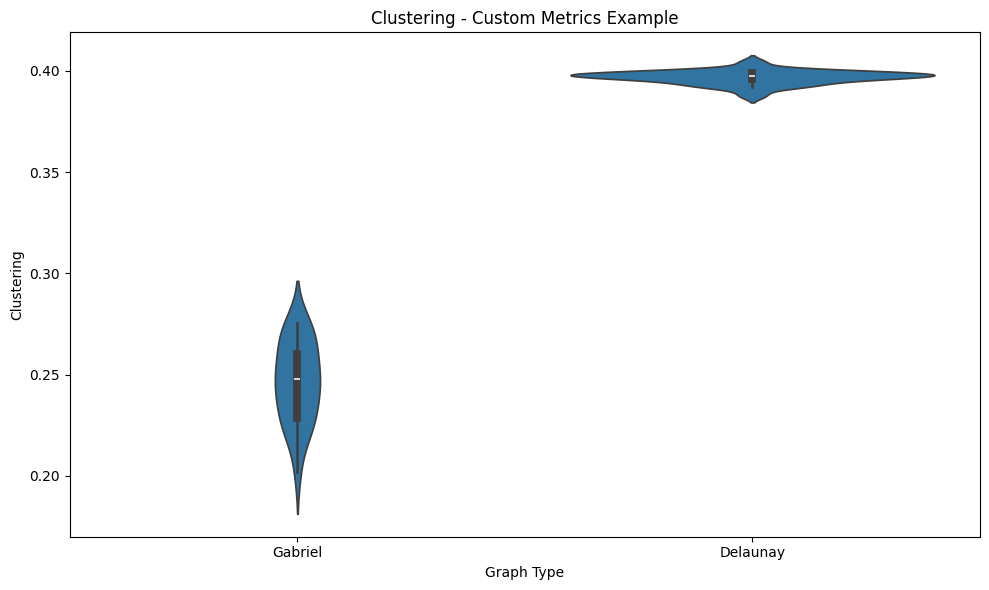

In [7]:
example_custom_metrics()

# EXAMPLE 4: Biological Graphs - Physarum

In [8]:
def example_biological_graphs():
    
    exp = Experiment(
        name="Physarum vs Traditional Graphs",
        point_config={
            'method': 'uniform_square',
            'params': {'n': 50}
        },
        n_simulations=15,
        seed=777,
        verbose=True
    )
    
    # Add traditional graphs
    exp.add_graph_config(pg.GG, name='Gabriel')
    exp.add_graph_config(pg.MST, name='MST')
    
    # Add Physarum with different configurations
    exp.add_graph_config(
        pg.PhysarumGraph,
        name='Physarum-Short',
        sources=[0],
        sinks=[49],
        steps=100,
        gamma=1.5,
        base_graph='delaunay'
    )
    
    exp.add_graph_config(
        pg.PhysarumGraph,
        name='Physarum-Long',
        sources=[0],
        sinks=[49],
        steps=300,
        gamma=2.0,
        base_graph='delaunay'
    )
    
    # Run
    results = exp.run()
    
    # Compare edge counts
    print("\nEdge Count Comparison:")
    print(results.groupby('graph_type')['n_edges'].describe())
    
    # Plot comparison
    fig, axes = exp.compare_metrics(['n_edges', 'mean_degree', 'mean_length', 'density'])
    fig.savefig(r'tests/Experiment_figs/ex4_physarum.png', dpi=150, bbox_inches='tight')
    
    return exp

c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:117: UserWarning: No graph configurations provided. Use add_graph_config().
  warnings.warn("No graph configurations provided. Use add_graph_config().")


Running experiment: Physarum vs Traditional Graphs
Simulations: 15
Graph types: 4
--------------------------------------------------
Progress: 1/15 simulations
Progress: 2/15 simulations
Progress: 3/15 simulations
Progress: 4/15 simulations
Progress: 5/15 simulations
Progress: 6/15 simulations
Progress: 7/15 simulations
Progress: 8/15 simulations
Progress: 9/15 simulations
Progress: 10/15 simulations
Progress: 11/15 simulations
Progress: 12/15 simulations
Progress: 13/15 simulations
Progress: 14/15 simulations
Progress: 15/15 simulations
--------------------------------------------------
Experiment complete. 60 results collected.

Edge Count Comparison:
                count       mean       std   min   25%   50%   75%   max
graph_type                                                              
Gabriel          15.0  85.066667  3.011091  81.0  83.5  85.0  86.5  92.0
MST              15.0  49.000000  0.000000  49.0  49.0  49.0  49.0  49.0
Physarum-Long    15.0   3.466667  2.133631   1

Experiment('Physarum vs Traditional Graphs', simulations=15, status=60 results)

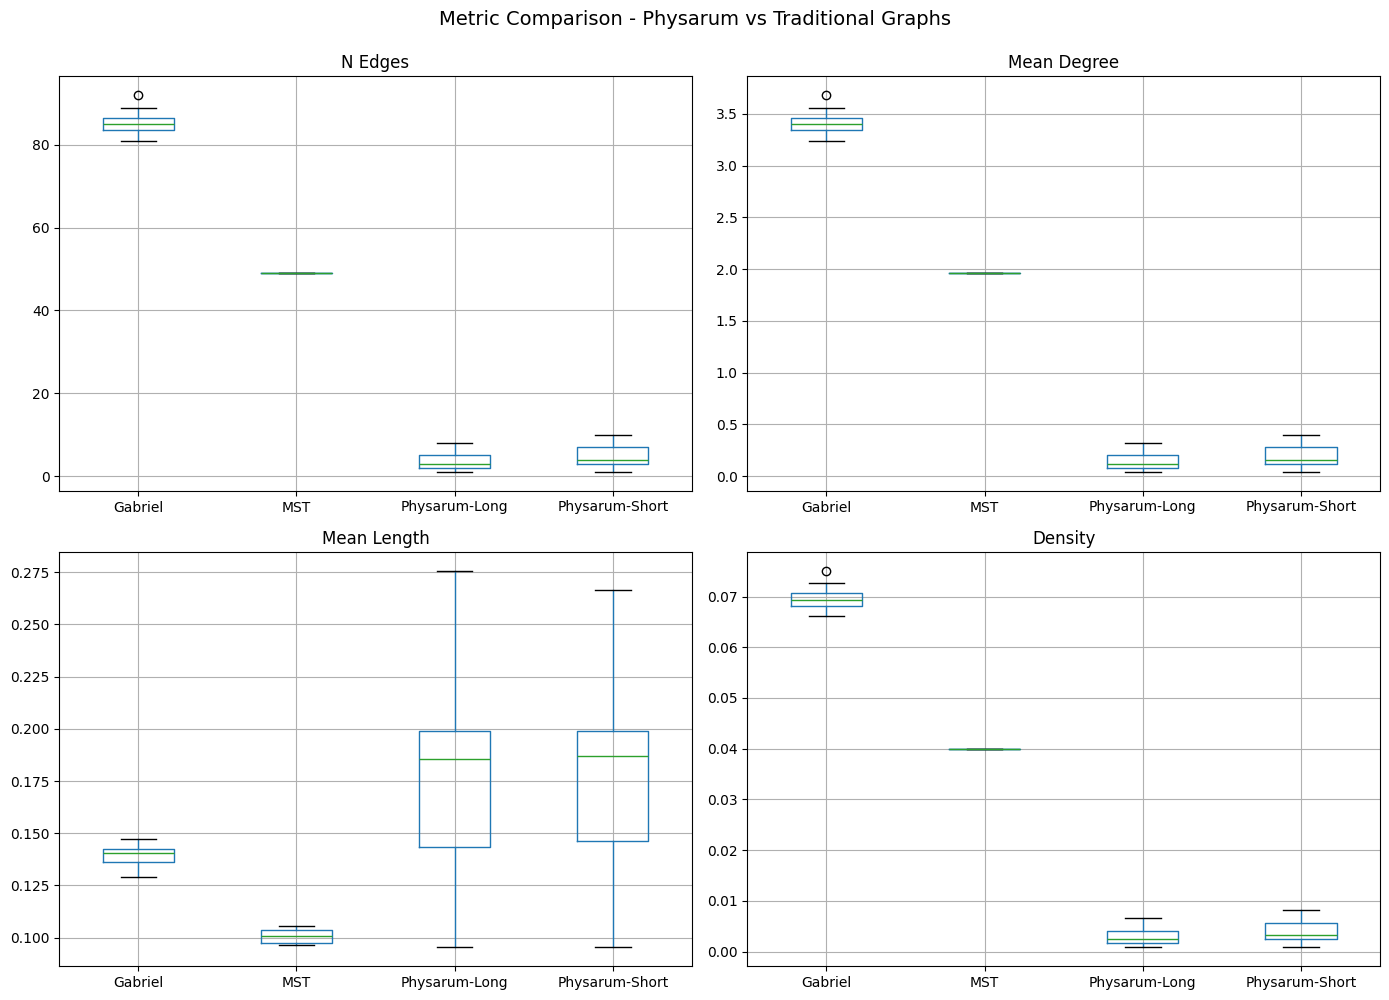

In [9]:
example_biological_graphs()

# EXAMPLE 5: Parameter Sweep

In [10]:
def example_parameter_sweep():
    
    beta_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    
    exp = Experiment(
        name="Beta-Skeleton Parameter Sweep",
        point_config={
            'method': 'uniform_square',
            'params': {'n': 100}
        },
        n_simulations=20,
        seed=2024
    )
    
    # Add configuration for each beta value
    for beta in beta_values:
        exp.add_graph_config(
            pg.Beta_Skeleton,
            name=f'Beta-{beta}',
            beta=beta,
            type_region='lune' if beta >= 1 else 'intersection'
        )
    
    # Run
    results = exp.run()
    
    # Plot evolution of metrics vs beta
    fig, ax = exp.plot_metric('mean_degree', kind='bar')
    ax.set_xlabel('Beta Parameter')
    fig.savefig(r'tests/Experiment_figs/ex5_beta_sweep.png', dpi=150, bbox_inches='tight')
    
    # Export detailed results
    exp.export_results(r'tests/Experimet_results/ex5_sweep_results.csv')
    
    return exp

c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:117: UserWarning: No graph configurations provided. Use add_graph_config().
  warnings.warn("No graph configurations provided. Use add_graph_config().")


Running experiment: Beta-Skeleton Parameter Sweep
Simulations: 20
Graph types: 6
--------------------------------------------------
Progress: 2/20 simulations
Progress: 4/20 simulations
Progress: 6/20 simulations
Progress: 8/20 simulations
Progress: 10/20 simulations
Progress: 12/20 simulations
Progress: 14/20 simulations
Progress: 16/20 simulations
Progress: 18/20 simulations
Progress: 20/20 simulations
--------------------------------------------------
Experiment complete. 120 results collected.
Results exported to tests/Experimet_results/ex5_sweep_results.csv


Experiment('Beta-Skeleton Parameter Sweep', simulations=20, status=120 results)

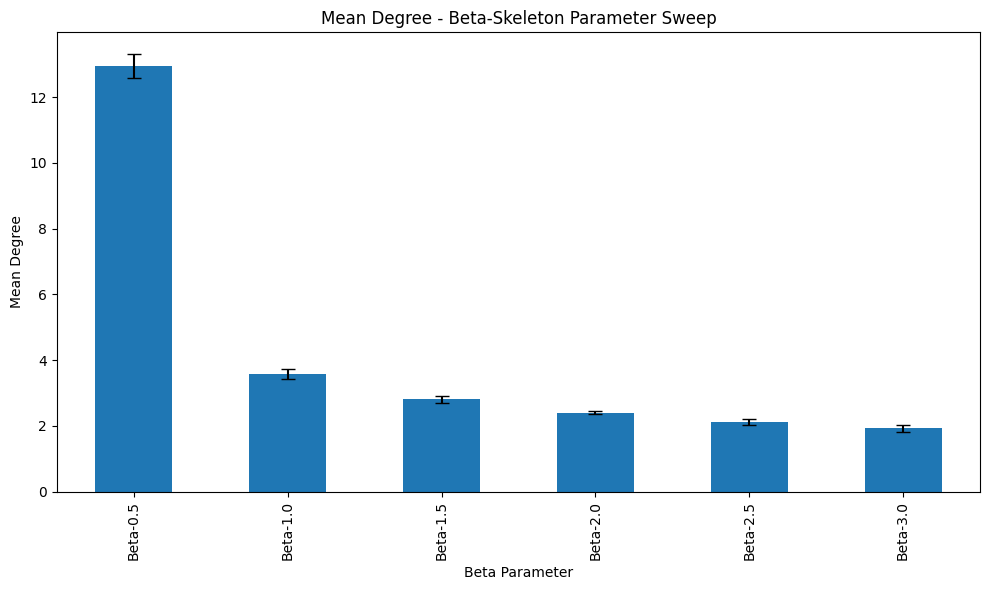

In [11]:
example_parameter_sweep()

# EXAMPLE 6: Different Point Distributions

In [12]:
def example_point_distributions():
    
    distributions = [
        {'method': 'uniform_square', 'params': {'n': 100}, 'label': 'Uniform'},
        {'method': 'normal_dist', 'params': {'n': 100}, 'label': 'Normal'},
        {'method': 'uniform_sphere', 'params': {'n': 100}, 'label': 'Circle'},
        {'method': 'poissonprocess_square', 'params': {'intensity': 100, 'limit': 1}, 'label': 'Poisson'},
    ]
    
    all_results = []
    
    for dist_config in distributions:
        exp = Experiment(
            name=f"GG on {dist_config['label']} Points",
            point_config={
                'method': dist_config['method'],
                'params': dist_config['params']
            },
            graph_configs=[
                {'class': pg.GG, 'params': {'closed': True}, 'name': dist_config['label']}
            ],
            n_simulations=30,
            seed=456,
            verbose=False
        )
        
        results = exp.run()
        all_results.append(results)
    
    # Combine results
    import pandas as pd
    combined = pd.concat(all_results, ignore_index=True)
    
    # Compare
    print("\nMean Degree by Distribution:")
    print(combined.groupby('graph_type')['mean_degree'].agg(['mean', 'std']))
    
    # Box plot comparison
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 6))
    combined.boxplot(column='mean_degree', by='graph_type', ax=ax)
    ax.set_title('Gabriel Graph: Mean Degree vs Point Distribution')
    ax.set_xlabel('Point Distribution')
    ax.set_ylabel('Mean Degree')
    plt.suptitle('')
    fig.savefig(r'tests/Experiment_figs/ex6_distributions.png', dpi=150, bbox_inches='tight')
    
    return combined


Mean Degree by Distribution:
                mean       std
graph_type                    
Circle      3.584667  0.155868
Normal      3.666667  0.123772
Poisson     3.578090  0.154244
Uniform     3.576000  0.107946


,simulation,graph_type,n_vertices,n_edges,n_components,n_faces,mean_degree,std_degree,min_degree,max_degree,mean_length,std_length,min_length,max_length,total_length,entropy_degree,entropy_length,entropy_orientation,is_connected,density
0,0,Uniform,100,180,1,82,3.600000,1.122497,1,7,0.103558,0.054893,0.010018,0.269467,18.640502,2.182623,2.933179,5.054970,True,0.036364
1,1,Uniform,100,174,1,76,3.480000,1.034215,2,7,0.101673,0.057750,0.013404,0.269784,17.691135,2.029190,2.998427,4.980369,True,0.035152
2,2,Uniform,100,184,1,86,3.680000,1.047664,2,6,0.098360,0.048865,0.009550,0.266757,18.098178,2.075242,2.879066,4.992177,True,0.037172
3,3,Uniform,100,182,1,84,3.640000,1.135958,1,7,0.101513,0.049690,0.001688,0.253578,18.475379,2.208059,2.929203,5.021635,True,0.036768
4,4,Uniform,100,180,1,82,3.600000,1.086278,2,7,0.100016,0.056480,0.005329,0.251532,18.002902,2.104521,3.074982,5.088642,True,0.036364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,25,Poisson,95,164,1,71,3.452632,0.867767,2,6,0.098043,0.052001,0.008272,0.254441,16.079080,1.801304,2.981587,5.023933,True,0.036730
116,26,Poisson,127,233,1,108,3.669291,1.164130,1,6,0.083562,0.043997,0.004338,0.330205,19.469950,2.223303,2.303980,5.122950,True,0.029121
117,27,Poisson,118,223,1,107,3.779661,1.090293,2,6,0.091801,0.046759,0.003343,0.248279,20.471545,2.123032,2.818766,5.071520,True,0.032305
118,28,Poisson,105,170,1,67,3.238095,0.899987,1,6,0.088020,0.050135,0.003906,0.270428,14.963362,1.856751,2.846273,5.029204,True,0.031136


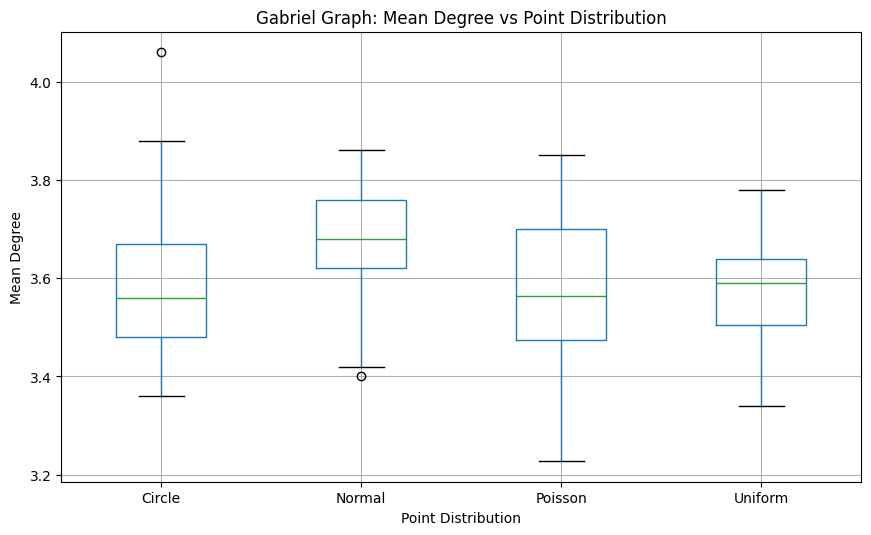

In [13]:
example_point_distributions()

# EXAMPLE 7: Storing and Retrieving Graphs

Axes compose no funciona

In [14]:
def example_graph_storage():
    
    exp = Experiment(
        name="Store Graphs Example",
        point_config={
            'method': 'uniform_square',
            'params': {'n': 50}
        },
        graph_configs=[
            {'class': pg.GG, 'name': 'Gabriel'},
            {'class': pg.RNG, 'name': 'RNG'}
        ],
        n_simulations=5,
        seed=111
    )
    
    # Run with graph storage enabled
    results = exp.run(store_graphs=True)
    
    # Retrieve specific graphs
    gabriel_0 = exp.get_graph(simulation=0, graph_type='Gabriel')
    rng_0 = exp.get_graph(simulation=0, graph_type='RNG')
    
    if gabriel_0 and rng_0:
        # Visualize
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        gabriel_0.draw(
            figsize=(7, 6),
            v_size=20,
            e_size=0.8,
            title=True,
            axis=False,
            save=None
        )
        plt.sca(axes[0])
        
        rng_0.draw(
            figsize=(7, 6),
            v_size=20,
            e_size=0.8,
            title=True,
            axis=False,
            save=None
        )
        plt.sca(axes[1])
        
        #fig.savefig(r'tests/Experiment_figs/ex7_stored_graphs.png', dpi=150, bbox_inches='tight')
    
    return exp

Running experiment: Store Graphs Example
Simulations: 5
Graph types: 2
--------------------------------------------------
Progress: 1/5 simulations
Progress: 2/5 simulations
Progress: 3/5 simulations
Progress: 4/5 simulations
Progress: 5/5 simulations
--------------------------------------------------
Experiment complete. 10 results collected.


Experiment('Store Graphs Example', simulations=5, status=10 results)

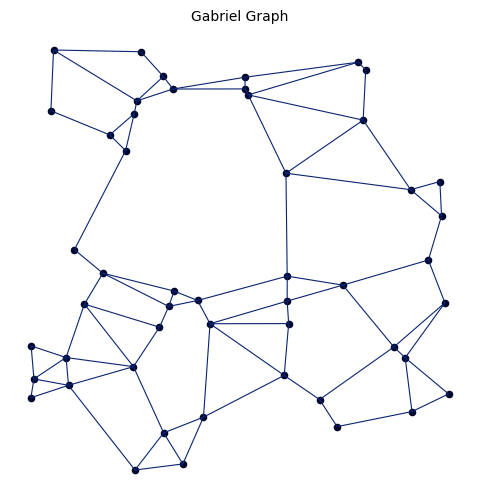

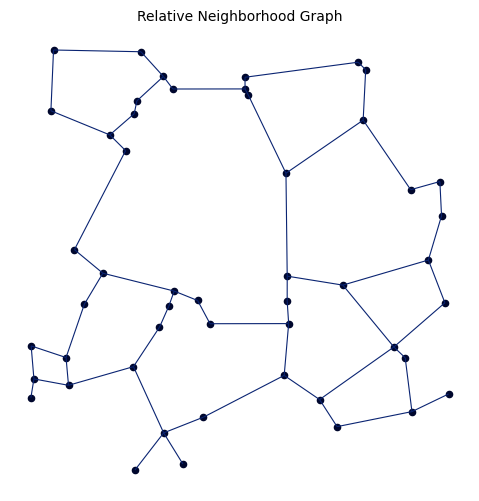

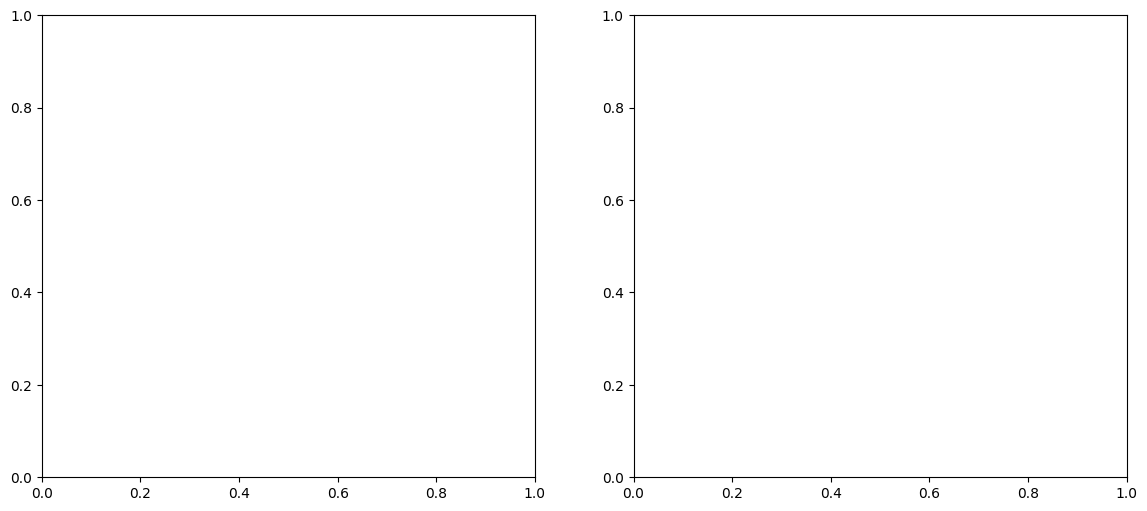

In [15]:
example_graph_storage()

# EXAMPLE 8: Advanced - Entropy Analysis

In [16]:
def example_entropy_analysis():
    """Analyze entropy metrics across graph types."""
    
    exp = Experiment(
        name="Entropy Analysis",
        point_config={
            'method': 'uniform_square',
            'params': {'n': 120}
        },
        graph_configs=[
            {'class': pg.GG, 'name': 'Gabriel'},
            {'class': pg.RNG, 'name': 'RNG'},
            {'class': pg.DelaunayG, 'name': 'Delaunay'},
            {'class': pg.Beta_Skeleton, 'name': 'Beta-1.5', 'params': {'beta': 1.5}}
        ],
        n_simulations=40,
        seed=888
    )
    
    # Run
    results = exp.run()
    
    # Focus on entropy metrics
    entropy_metrics = ['entropy_degree', 'entropy_length', 'entropy_orientation']
    
    print("\nEntropy Metrics Summary:")
    print(results.groupby('graph_type')[entropy_metrics].mean())
    
    # Visualize
    fig, axes = exp.compare_metrics(entropy_metrics, figsize=(12, 5))
    fig.savefig(r'tests/Experiment_figs/ex8_entropy.png', dpi=150, bbox_inches='tight')
    
    return exp


Running experiment: Entropy Analysis
Simulations: 40
Graph types: 4
--------------------------------------------------
Progress: 4/40 simulations
Progress: 8/40 simulations
Progress: 12/40 simulations
Progress: 16/40 simulations
Progress: 20/40 simulations
Progress: 24/40 simulations
Progress: 28/40 simulations
Progress: 32/40 simulations
Progress: 36/40 simulations
Progress: 40/40 simulations
--------------------------------------------------
Experiment complete. 160 results collected.

Entropy Metrics Summary:
            entropy_degree  entropy_length  entropy_orientation
graph_type                                                     
Beta-1.5          1.733967        2.889976             5.019147
Delaunay          2.369917        1.856518             5.095932
Gabriel           2.139513        2.902197             5.056555
RNG               1.453369        2.884252             4.983676


Experiment('Entropy Analysis', simulations=40, status=160 results)

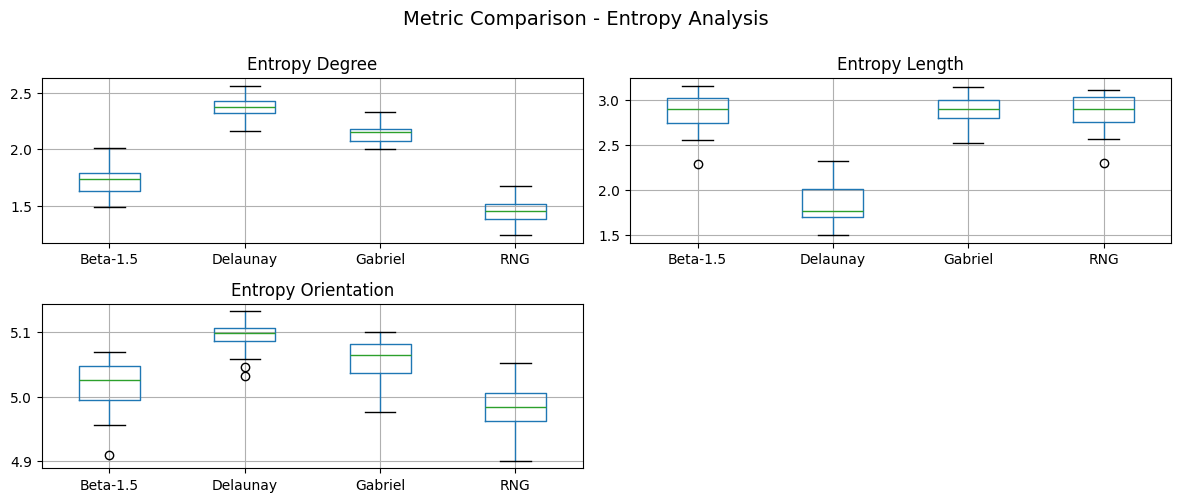

In [17]:
example_entropy_analysis()

# EXAMPLE 9: Point Transformations

In [22]:
def example_point_transformations():
    """Demonstrate point transformations in experiments."""
    
    # Example 1: Rotation
    exp1 = Experiment(
        name="Gabriel on Rotated Grid",
        point_config={
            'method': 'uniform_square',
            'params': {'n': 100},
            'transformations': [
                {'method': 'rotation', 'params': {'angle': 45, 'degree': True}}
            ]
        },
        graph_configs=[
            {'class': pg.GG, 'name': 'Gabriel'}
        ],
        n_simulations=10,
        seed=111
    )
    
    results1 = exp1.run(store_graphs=True)
    
    # Visualize one rotated graph
    g = exp1.get_graph(0, 'Gabriel')
    if g:
        fig, ax = g.draw(figsize=(8, 8), title=True)
        fig.savefig(r'tests/Experiment_figs/ex9_rotated_grid.png', dpi=150, bbox_inches='tight')
    
    # Example 2: Multiple transformations
    exp2 = Experiment(
        name="Transformed Uniform Points",
        n_simulations=20,
        seed=222
    )
    
    exp2.add_point_config(
        'uniform_square',
        n=100,
        transformations=[
            {'method': 'rotation', 'params': {'angle': 30}},
            {'method': 'scaling', 'params': {'scale': 2.0}},
            {'method': 'traslation', 'params': {'c': [0.5, 0.5]}}
        ]
    )
    
    exp2.add_graph_config(pg.GG, name='Gabriel')
    exp2.add_graph_config(pg.RNG, name='RNG')
    
    results2 = exp2.run()
    print("\nResults with multiple transformations:")
    print(results2.groupby('graph_type')[['mean_degree', 'n_edges']].mean())
    
    # Example 3: Perturbation (useful for robustness testing)
    exp3 = Experiment(
        name="Grid with Perturbation",
        n_simulations=25,
        seed=333
    )
    
    exp3.add_point_config(
        'uniform_square',
        n=144,
        transformations=[
            {'method': 'perturb', 'params': {'radius': 0.1}}
        ]
    )
    
    exp3.add_graph_config(pg.GG, name='Gabriel')
    exp3.add_graph_config(pg.DelaunayG, name='Delaunay')
    
    results3 = exp3.run()
    
    # Compare with and without perturbation
    fig, ax = exp3.plot_metric('mean_degree', kind='box')
    ax.set_title('Effect of Perturbation on Grid Graphs')
    fig.savefig(r'tests/Experiment_figs/ex9_perturbation.png', dpi=150, bbox_inches='tight')
    
    return exp1, exp2, exp3

Running experiment: Gabriel on Rotated Grid
Simulations: 10
Graph types: 1
--------------------------------------------------
Progress: 1/10 simulations
Progress: 2/10 simulations
Progress: 3/10 simulations
Progress: 4/10 simulations
Progress: 5/10 simulations
Progress: 6/10 simulations
Progress: 7/10 simulations
Progress: 8/10 simulations
Progress: 9/10 simulations
Progress: 10/10 simulations
--------------------------------------------------
Experiment complete. 10 results collected.
Running experiment: Transformed Uniform Points
Simulations: 20
Graph types: 2
--------------------------------------------------
Progress: 2/20 simulations
Progress: 4/20 simulations


c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:114: UserWarning: No point configuration provided. Use add_point_config().
  warnings.warn("No point configuration provided. Use add_point_config().")
c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:117: UserWarning: No graph configurations provided. Use add_graph_config().
  warnings.warn("No graph configurations provided. Use add_graph_config().")


Progress: 6/20 simulations
Progress: 8/20 simulations
Progress: 10/20 simulations
Progress: 12/20 simulations
Progress: 14/20 simulations
Progress: 16/20 simulations
Progress: 18/20 simulations
Progress: 20/20 simulations
--------------------------------------------------
Experiment complete. 40 results collected.

Results with multiple transformations:
            mean_degree  n_edges
graph_type                      
Gabriel           3.556    177.8
RNG               2.378    118.9
Running experiment: Grid with Perturbation
Simulations: 25
Graph types: 2
--------------------------------------------------
Progress: 2/25 simulations
Progress: 4/25 simulations
Progress: 6/25 simulations
Progress: 8/25 simulations
Progress: 10/25 simulations
Progress: 12/25 simulations
Progress: 14/25 simulations
Progress: 16/25 simulations


c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:114: UserWarning: No point configuration provided. Use add_point_config().
  warnings.warn("No point configuration provided. Use add_point_config().")
c:\CODE\Python\app_pg\proximitygraphs\proximitygraphs\experiments.py:117: UserWarning: No graph configurations provided. Use add_graph_config().
  warnings.warn("No graph configurations provided. Use add_graph_config().")


Progress: 18/25 simulations
Progress: 20/25 simulations
Progress: 22/25 simulations
Progress: 24/25 simulations
--------------------------------------------------
Experiment complete. 50 results collected.


(Experiment('Gabriel on Rotated Grid', simulations=10, status=10 results),
 Experiment('Transformed Uniform Points', simulations=20, status=40 results),
 Experiment('Grid with Perturbation', simulations=25, status=50 results))

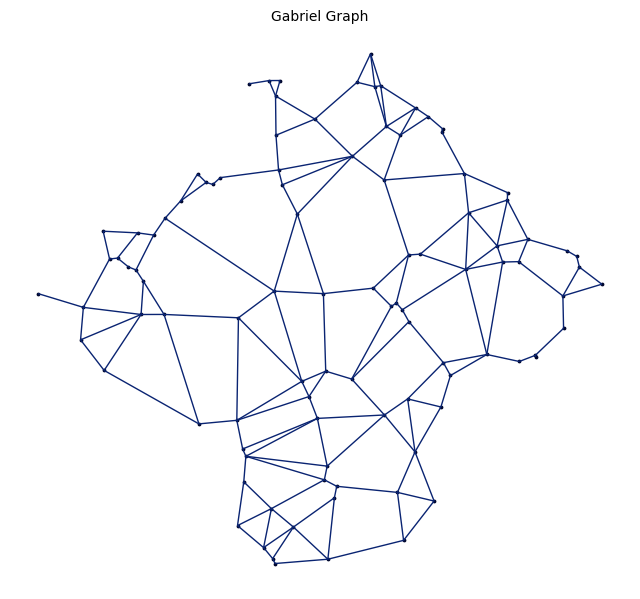

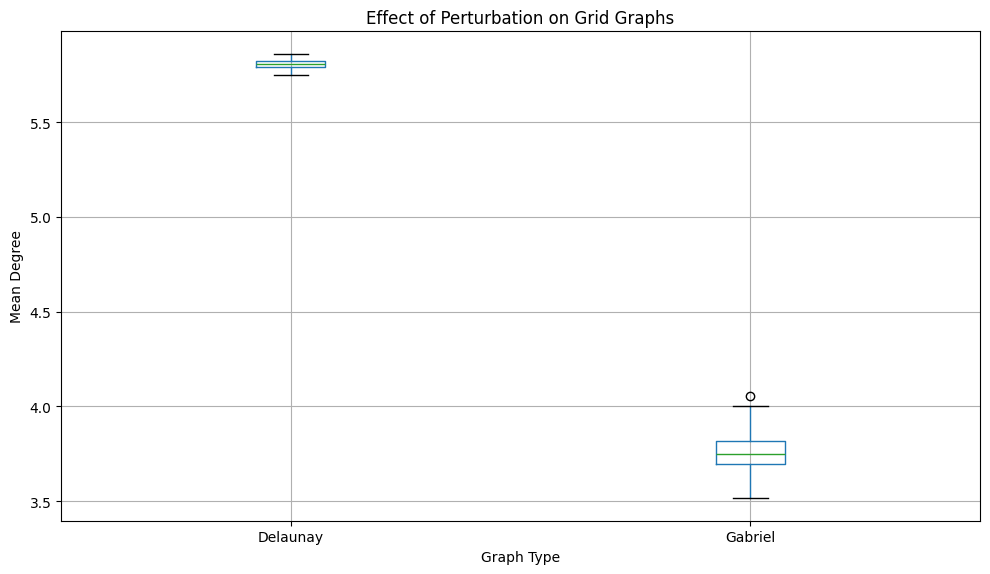

In [23]:
example_point_transformations()